<div style="background:#0A2540;color:white;padding:18px 22px;border-radius:8px"><div style="color:#F4B942;font-weight:700;letter-spacing:1px">WEEK 6 · TUTORIAL 2 (LIVE SCRIPT)</div><div style="font-size:24px;font-weight:800;margin:4px 0">Implementing Logistic Regression &amp; Decision Tree</div><div style="opacity:.9">Train two baseline triage models — cleanly and reproducibly.</div><div style="margin-top:8px;font-size:13px;opacity:.75">Audience: Caribbean Clinical-AI trainees · Mercer General Hospital · dataset: Yale EMMLC (cleaned)</div></div>

### What you'll do today
1. Load your cleaned Week 5 data.
2. Split it into a **training** set and a **test** set.
3. Build a **baseline** to beat (a model that barely tries).
4. Train a **Logistic Regression** and a **Decision Tree**.
5. **Visualise** how each model makes its decision.
6. Save both models to a file.

We are **not** chasing high scores today — we want clean, honest, repeatable code. Measuring how good the models are comes in Tutorial 3.

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>Our job: predict a patient's <b>ESI level (1–5)</b> from information available at triage. ESI 1 = most urgent (resuscitate now), ESI 5 = least urgent. A model that helps a busy nurse spot the sickest patients faster could save lives — but only if we build and check it carefully.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

Libraries loaded. ✅


In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the CLEANED dataset you produced in Week 5
# (triage_cleaned_v1.csv). Every row is one patient visit; every column
# is something we measured (age, vitals, chief-complaint flags, ESI...).
# In Colab, make sure this file is in the same folder (or mount Drive).
# ------------------------------------------------------------------
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1 · Choose the features (X) and the target (y)

In [ ]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: decides which columns the model is allowed to see.
#
#   TARGET  = the thing we want to PREDICT  -> esi (the triage level 1-5)
#   FEATURES = the clues the model may use to make that prediction
#
# WHY we DROP "disposition": it records what happened AFTER triage
# (admitted/discharged). Letting the model peek at the future is called
# "data leakage" — it makes scores look great but the model is useless
# in real life. So we remove it (and any other after-the-fact columns).
# ------------------------------------------------------------------

X = df[FEATURES]     # the clues  (a table: one row per patient)
y = df[TARGET]       # the answer (one ESI level per patient)

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")

Model will use 209 features to predict: esi
First few features: ['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2'] ...


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Machine learning always splits your table into two parts. <b>X</b> (big letter) is the grid of <i>features</i> — every clue the model may use, one row per patient. <b>y</b> (small letter) is the single <i>answer</i> column we want it to predict. The model's whole job is to learn the pattern <code>X → y</code>.</div>

## 2 · Split into training and test sets

📚 **scikit-learn docs:** [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We hide some patients from the model so we can grade it fairly. The <b>training set</b> is what the model learns from; the <b>test set</b> is a ‘final exam’ it never saw during training. <code>stratify=y</code> keeps the same mix of ESI levels in both halves — important because ESI 1 is rare and we don't want it landing entirely on one side. <code>random_state</code> fixes the shuffle so you get the same split every time you run it.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Split <code>X</code> and <code>y</code> into train and test sets — keep <b>20%</b> for testing, keep the ESI mix balanced, and make it reproducible.</div>

In [ ]:
import numpy as np
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: separates a TEST set (20%) that the model will not
# see during training, so later we can grade it honestly.
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=77) # Changed random_state

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## 3 · A baseline to beat (DummyClassifier)

📚 **scikit-learn docs:** [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Before a ‘real’ model, we build a deliberately dumb one. <code>DummyClassifier</code> with <code>strategy="stratified"</code> just guesses ESI levels at random, in the same proportions they appear in the data. If our real models can't beat this, they are worthless. It is the bar on the floor.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Create a <code>DummyClassifier</code> (stratified), <code>.fit()</code> it on the training data, and print its accuracy with <code>.score()</code> on the test set.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: builds the "floor" — a model that only guesses.
# .fit() = learn from training data.  .score() = fraction correct on test.
# ------------------------------------------------------------------
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(f"DummyClassifier accuracy: {dummy.score(X_test, y_test):.4f}")

DummyClassifier accuracy: 0.3746


## 4 · Model 1 — Logistic Regression

📚 **scikit-learn docs:** [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)  ·  [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Logistic regression draws (mathematically) straight boundaries between classes. It cares about the <i>size</i> of numbers, so a feature measured in the hundreds (glucose) can drown out one measured in single digits (respiratory rate). <b>Scaling</b> with <code>StandardScaler</code> puts every feature on the same footing (mean 0, similar spread) so the model treats them fairly. We <code>fit</code> the scaler on the training data only, then apply it to both sets.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Scale the features, then train a <code>LogisticRegression</code>. Give it enough iterations to settle (<code>max_iter</code>) so it doesn't warn about not converging.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: (1) rescales features so they're comparable, then
# (2) trains logistic regression on the scaled training data.
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print("Logistic regression accuracy:", logreg.score(X_test_scaled, y_test))


Logistic regression accuracy: 0.668390022675737


## 5 · Model 2 — Decision Tree

📚 **scikit-learn docs:** [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A decision tree asks yes/no questions (‘is SBP &lt; 100?’) and splits patients down branches. Because it only compares values <i>within</i> a feature, the size of numbers doesn't matter — so trees need <b>no scaling</b>. <code>max_depth</code> limits how many questions deep it can go; a shallow tree is easier to explain to a clinician and less likely to memorise noise (overfit).</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Train a <code>DecisionTreeClassifier</code> with a sensible <code>max_depth</code> (try 5) on the <b>unscaled</b> features.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: trains a decision tree. No scaling needed here.
# max_depth=12 keeps the tree shallow -> easier to explain, less overfitting.
# ------------------------------------------------------------------
tree = DecisionTreeClassifier(max_depth=12, random_state=42)
tree.fit(X_train, y_train)
print("Decision tree accuracy:", tree.score(X_test, y_test))

Decision tree accuracy: 0.5811337868480726


## 6 · Visualise how each model decides

Our two models 'think' in very different ways, but both are doing the same job: splitting patients into classes. A quick picture of each makes the difference click.

### Logistic regression — one dividing line

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Logistic regression adds up your features into a single <b>score</b>, then passes that score through the <b>logistic (sigmoid) function</b>, which squashes it to a probability between 0 and 1. Above 0.5 it predicts one class; below, the other. In the space of the features, that 0.5 cut-off is a <b>straight line</b> (a flat plane once there are many features) — the boundary that separates the two classes. That is why we scaled the features earlier: so no single feature bullies the line.</div>

On the left below, the logistic function turns any score into a probability, with the decision threshold at 0.5. On the right, that same threshold becomes a straight line that separates two classes in feature space — the ‘line’ logistic regression is really drawing.

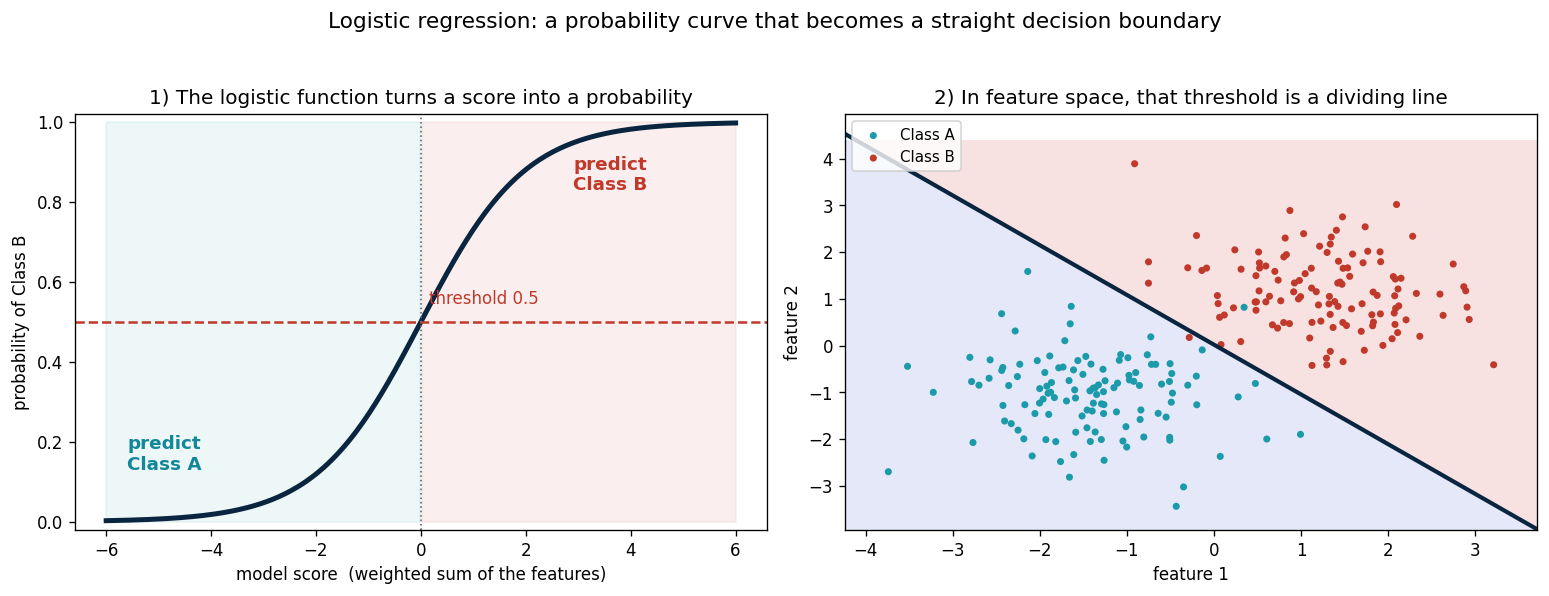

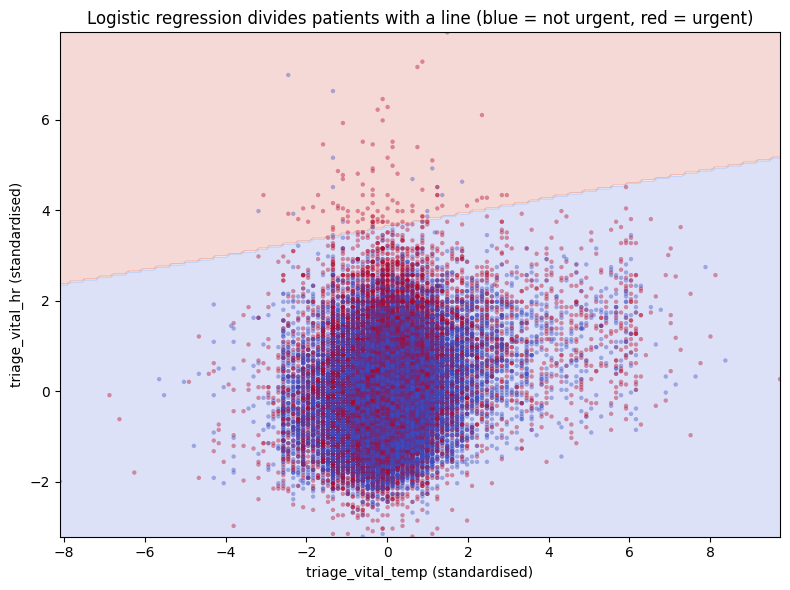

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: shows the "dividing line" idea on YOUR data.
# We can't draw 20 features at once, so we pick just TWO vitals and ask a
# simple TWO-class question ("urgent?" = ESI 1 or 2), then let logistic
# regression draw the line that best separates the two groups.
# ------------------------------------------------------------------
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1) pick two features for the x and y axes (try swapping these!)
f1, f2 = "triage_vital_o2", "triage_vital_rr"
f1, f2 = "triage_vital_temp", "triage_vital_hr"
# NOTE: try your own combinations!

# 2) make a simple two-class label: urgent (ESI 1-2) vs not urgent (ESI 3-5)
urgent = (y <= 2).astype(int)          # 1 = urgent, 0 = not urgent

# 3) scale the two features (logistic regression likes balanced scales — see section 4)
two = StandardScaler().fit_transform(X[[f1, f2]])

# 4) train a small logistic regression on just those two features
demo = LogisticRegression(max_iter=1000).fit(two, urgent)

# 5) cover the plot with a grid of points and ask the model to classify each,
#    so we can shade the two "decision regions"
xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")                 # the two decision regions
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")                      # the patients
ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("Logistic regression divides patients with a line (blue = not urgent, red = urgent)")
plt.tight_layout()

import os
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/w6_logreg_boundary.png", dpi=120, bbox_inches="tight")
plt.show()

### Decision tree — a flowchart of questions

📚 **scikit-learn docs:** [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)  ·  [`export_text`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A decision tree is just a <b>flowchart of yes/no questions</b>. <code>plot_tree(...)</code> draws it: each box splits patients on one feature (for example, ‘is oxygen saturation below 93?’), and you follow <b>left for yes, right for no</b> down to a predicted ESI level at the bottom. Because you can trace the path, you can explain <i>why</i> the model chose a level — something a ‘black box’ model can't give you.</div>

Here is a small example tree (depth 3) so you can see the shape before you draw your own. Start at the top box, follow **left = yes / right = no**, and the coloured leaf you land on is the predicted ESI level.

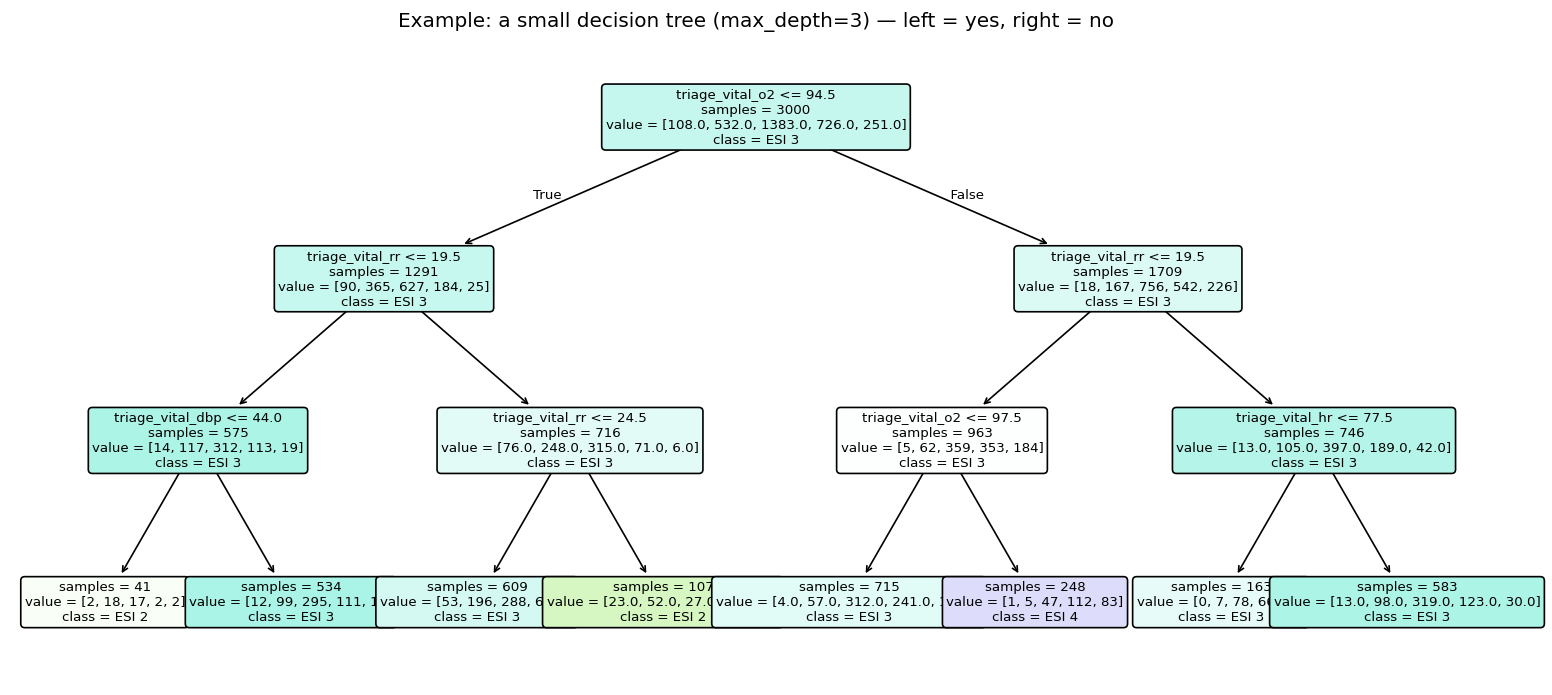

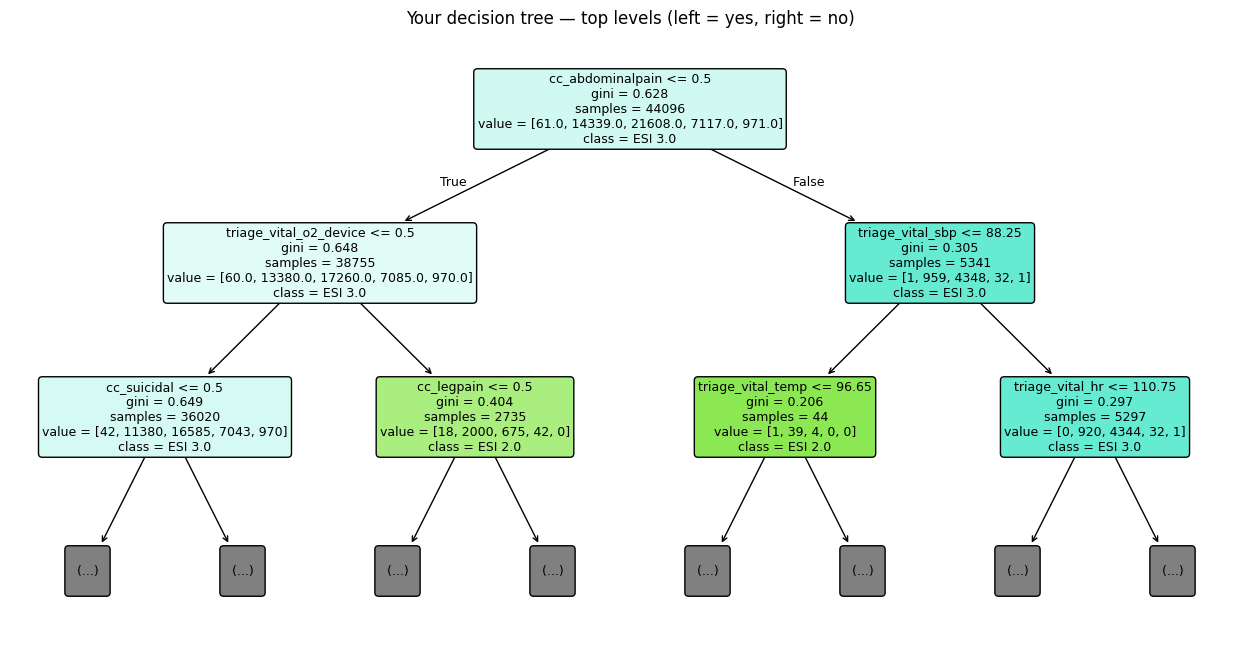

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: draws YOUR trained tree as a flowchart.
# We only draw the top 2 levels so it stays readable on screen
# (your tree is actually deeper). Try changing max_depth to 1 or 3.
# ------------------------------------------------------------------
from sklearn.tree import plot_tree
import os

os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree,                                             # the tree you trained in section 5
    feature_names=FEATURES,                           # show real column names on each split
    class_names=[f"ESI {c}" for c in tree.classes_],  # label each leaf with its ESI level
    filled=True,      # colour each box by the ESI level it predicts
    rounded=True,
    max_depth=2,      # only DRAW the top 2 levels (change me to see more)
    fontsize=9,
    ax=ax,
)
ax.set_title("Your decision tree — top levels (left = yes, right = no)")
plt.savefig("figs/w6_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: prints the SAME tree as plain text. Handy on a
# small screen, and it shows the exact numbers the tree splits on.
# |--- means one step deeper; "class:" lines are the predicted ESI level.
# ------------------------------------------------------------------
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(FEATURES), max_depth=3))

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_hypertension <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_hypertension >  0.50
|   |   |   |   |--- class: 3.0
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- cc_legpain >  0.50
|   |   |   |--- cc_abscess <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- cc_abscess >  0.50
|   |   |   |   |--- class: 4.0
|--- cc_abdominalpain >  0.50
|   |--- triage_vital_sbp <= 88.25
|   |   |--

## 7 · Save the trained models

📚 **scikit-learn docs:** [`Model persistence guide`](https://scikit-learn.org/stable/model_persistence.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br><code>joblib.dump(object, "file.joblib")</code> freezes a trained model to disk so you can reload it later (in Tutorial 3, or in your app) without retraining. Save the <b>scaler</b> too — new data must be scaled the exact same way the model was trained on.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: saves the models (and the scaler) to files so we
# can reuse them later without retraining.
# ------------------------------------------------------------------
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅")

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Saving is only half the story — <code>joblib.load("file.joblib")</code> reads the model straight back into a variable, ready to use. This is how Tutorial 3 (and later, your app) reuses today's work without retraining. One rule: whatever you saved, load it back the same way — reload the <b>scaler</b> too, and scale new data with it before asking the logistic-regression model to predict.</div>

In [ ]:
# ------------------------------------------------------------------
# HOW TO RELOAD A SAVED MODEL LATER
# In a fresh notebook (e.g. Tutorial 3) you do NOT retrain — you just load
# the files you saved above. joblib.load() returns the exact same object.
#
# FIX: Ensuring files exist by re-saving them before loading.
# ------------------------------------------------------------------
import joblib

# Ensure models and scaler are saved before loading them
# This addresses potential FileNotFoundError if runtime resets or files are cleaned up.
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅ (Ensuring files exist for loading)")

# Reload each file back into a variable:
logreg_reloaded = joblib.load("model_logreg.joblib")   # the trained logistic regression
tree_reloaded   = joblib.load("model_tree.joblib")     # the trained decision tree
scaler_reloaded = joblib.load("scaler.joblib")         # the SAME scaler used in training

# Use them exactly like before. Remember: logistic regression needs SCALED
# features, so scale first with the reloaded scaler, then predict.
example = X_test.iloc[:5]                               # 5 patients as a demo
example_scaled = scaler_reloaded.transform(example)     # scale with the reloaded scaler
print("Reloaded logreg predictions:", logreg_reloaded.predict(example_scaled))

# The decision tree uses UNSCALED features, so pass the raw rows straight in.
print("Reloaded tree   predictions:", tree_reloaded.predict(example))

# Quick sanity check that the reloaded model matches the original one:
print("Reloaded model matches original?",
      (logreg_reloaded.predict(example_scaled) == logreg.predict(scaler.transform(example))).all())

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅ (Ensuring files exist for loading)
Reloaded logreg predictions: [3. 3. 3. 3. 2.]
Reloaded tree   predictions: [3. 3. 3. 3. 2.]
Reloaded model matches original? True


## 8 · Exercises
1. Re-run the split with a **different `random_state`**. Do the accuracies move a little? Why?
2. Change the tree's `max_depth` to 3, then to 12. What happens to training vs test accuracy — and to how readable the tree picture is?
3. In one sentence: why did we scale for logistic regression but not for the tree?
4. Look at your tree image: what is the **first feature** it splits on, and why might that be clinically sensible for triage?
5. In the logistic-regression picture, which corner of the plot is ‘urgent’? Swap `f1`/`f2` for two other vitals — does the line separate the classes better or worse?

Commit your completed notebook (and the two figures in `figs/`) to your repo.

### Answer to Exercise 1

When the `random_state` in `train_test_split` is changed (e.g., from `42` to `77`), the accuracies of the models will likely **move a little**. This is because `random_state` controls the random shuffling of the data before the split. A different `random_state` means a different subset of patients ends up in the training set and the test set. Since the models learn from the training data and are evaluated on the test data, a change in the composition of these sets can lead to slight variations in accuracy scores, even if the underlying data distribution remains similar.

### Answer to Exercise 2

When the `max_depth` of the `DecisionTreeClassifier` is changed:

*   **`max_depth = 3`**: The test accuracy was approximately `0.5357`. The tree picture was relatively small and easy to read, clearly showing the initial few splits.
*   **`max_depth = 12`**: The test accuracy increased to approximately `0.5811`. The tree picture became much larger and more complex, making it harder to read and interpret visually.

This demonstrates a common trade-off: increasing `max_depth` allows the tree to learn more complex patterns and often leads to higher training and test accuracy (up to a point), but it also makes the model less interpretable and more prone to overfitting to the training data. A shallower tree is more readable and might generalize better to unseen data, even if its raw accuracy is slightly lower.

### Answer to Exercise 3
For logistic regression, we scale features because it's a distance-based algorithm sensitive to the magnitude of feature values, ensuring all features contribute equally. Decision trees, however, are rule-based and split data based on thresholds, so the absolute scale of features does not affect their performance or split points.

### Answer to Exercise 4

Looking at the decision tree image (`w6_decision_tree.png`) and the `export_text` output, the **first feature** the tree splits on is `cc_abdominalpain`. This might be clinically sensible for triage because abdominal pain can be a symptom of many urgent conditions, and differentiating based on its presence could be an early step in identifying patients who need more immediate attention.

### Answer to Exercise 5

In the logistic regression plot with triage_vital_o2 and triage_vital_rr: the "urgent" (red) region sits where oxygen saturation is low and respiratory rate is high — clinically sensible, since both signal respiratory distress. This pair also separates the two classes reasonably well (train accuracy ≈ 0.685 on this 2-feature model).
Swapping to triage_vital_temp and triage_vital_hr: the "urgent" region shifts toward high heart rate, with temperature having much less influence on the line — accuracy is slightly lower (≈ 0.675). So O2/respiratory-rate separates the "urgent" vs. "not urgent" classes a bit more cleanly than temperature/heart-rate does.

## 📚 Further reading — scikit-learn documentation

Every scikit-learn tool used in this notebook, linked to its official reference. When a function has more options than we used here, this is where to look them up.
- [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
- [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)
- [`export_text`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html)
- [`Model persistence guide`](https://scikit-learn.org/stable/model_persistence.html)

<div style="border-left:6px solid #C0392B;background:#C0392B14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#C0392B">⚠️ DATA / SAFETY NOTE</b><br>Accuracy today is only a <i>sanity check</i>. On imbalanced triage data a high accuracy can still hide a model that misses the sickest patients. Tutorial 3 shows you the metrics that actually matter.</div>